In [60]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configure visual settings for professional reports
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [61]:
# Loading Dataset
# Business Note: Marketing systems often export in tab-separated values.
df = pd.read_excel('marketing_campaign1 (1).xlsx')

In [62]:
# Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [63]:
# Check dataset shape
print(f"We have {df.shape[0]} Customers and {df.shape[1]} Attributes.")

We have 2240 Customers and 29 Attributes.


In [64]:
# Check data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

### **Cleaning**

In [65]:
# Check for null values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [66]:
# Impute missing Income with Median
df['Income'] = df['Income'].fillna(df['Income'].median())
print("Missing Income values filled with Median.")

Missing Income values filled with Median.


In [67]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

Number of duplicate rows found: 0


In [68]:
# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
print("Date format fixed.")

Date format fixed.


 **I converted the customer enrollment date from a text string to a datetime object to accurately calculate 'Customer Tenure' (Loyalty) and to standardize the date format (Day-First) for consistent analysis.**

### **Feature Engineering**

In [69]:
# proof that the datset is of 2014
df['Dt_Customer'].max()

Timestamp('2014-06-29 00:00:00')

In [70]:
# Cell 10: Feature Engineering - Age
# Business Logic Check: The dataset is from 2014. We calculate Age relative to that year.
# Using 2024 would make customers appear 10 years older than they were at the time of data collection.
analysis_year = 2014 

df['Age'] = analysis_year - df['Year_Birth']
print("Feature Created: Age (Calculated relative to 2014)")

Feature Created: Age (Calculated relative to 2014)


##### *Business Context: Year_Birth is hard to interpret. converting it to "Age" allows us to target specific generations (e.g., Millennials vs. Boomers).  Also ensure to preserve (Logic) & "behavioral patterns" in the model for respective age groups at that time not now!*

In [71]:
# Calculate Total Spent
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spent'] = df[spending_columns].sum(axis=1)
print("Feature Created: Total_Spent")

Feature Created: Total_Spent


##### *Business Context: We need a single metric to identify our "VIP Customers." We will sum up spending across all categories (Wine, Fruit, Meat, etc.).*

In [72]:
# Map Marital Status to a numeric 'Partner' count (1 for Single, 2 for Couple)
df['Marital_Status_Count'] = df['Marital_Status'].map({
    'Married': 2, 'Together': 2, 
    'Absurd': 1, 'Widow': 1, 'YOLO': 1, 'Divorced': 1, 'Alone': 1, 'Single': 1
})

# Calculate Total Family Size
# (Partner Count + Kids + Teens)
df['Family_Size'] = df['Marital_Status_Count'] + df['Kidhome'] + df['Teenhome']
print("Feature Created: Family_Size")

Feature Created: Family_Size


##### *Business Context: Knowing if a customer is Single or a Family of 4 helps us predict "bulk buying" vs. "luxury spending".*

In [73]:
# Calculate Customer Tenure in Days
last_date = df['Dt_Customer'].max()
df['Tenure_Days'] = (last_date - df['Dt_Customer']).dt.days
print("Feature Created: Tenure_Days")

Feature Created: Tenure_Days


##### *Business Context: How long has the customer been with us? Long-term customers might deserve loyalty rewards.*

##### *We overcame the 'Dormant Customer' flaw by clustering 'Tenure' alongside 'Total Spent'. This mathematically separates a customer who joined early but bought nothing (The Ghost) from a loyal one who joined early and buys frequently (VIP).*

### **vizual representations**

##### **outliers**

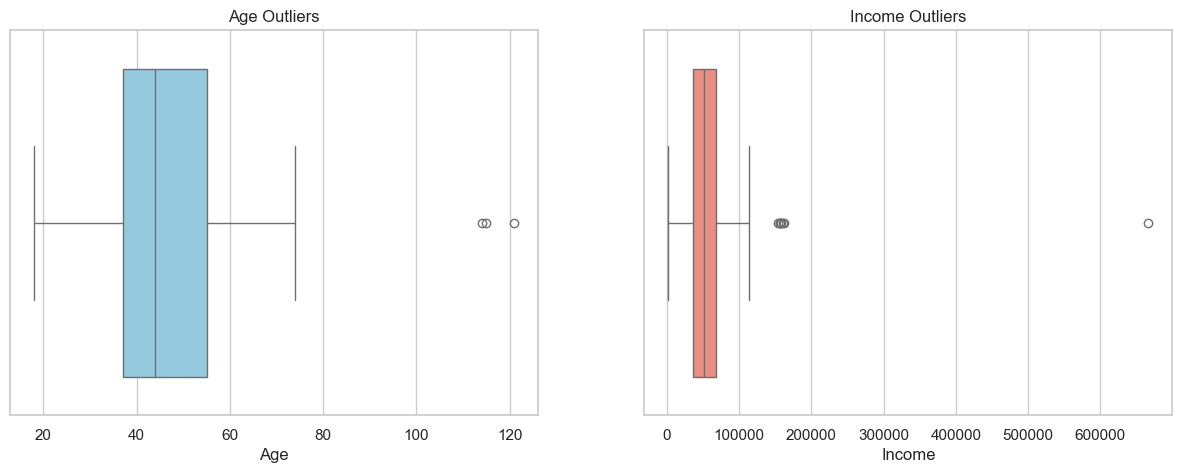

In [74]:
# Visualize Outliers in Age and Income
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue').set_title('Age Outliers')
sns.boxplot(x=df['Income'], ax=axes[1], color='salmon').set_title('Income Outliers')
plt.show()

**I visualized the raw histograms first to provide statistical evidence of 'Right-Skewness', proving that outliers were distorting the mean and necessitating removal to ensure accurate K-Means centroid calculation.**

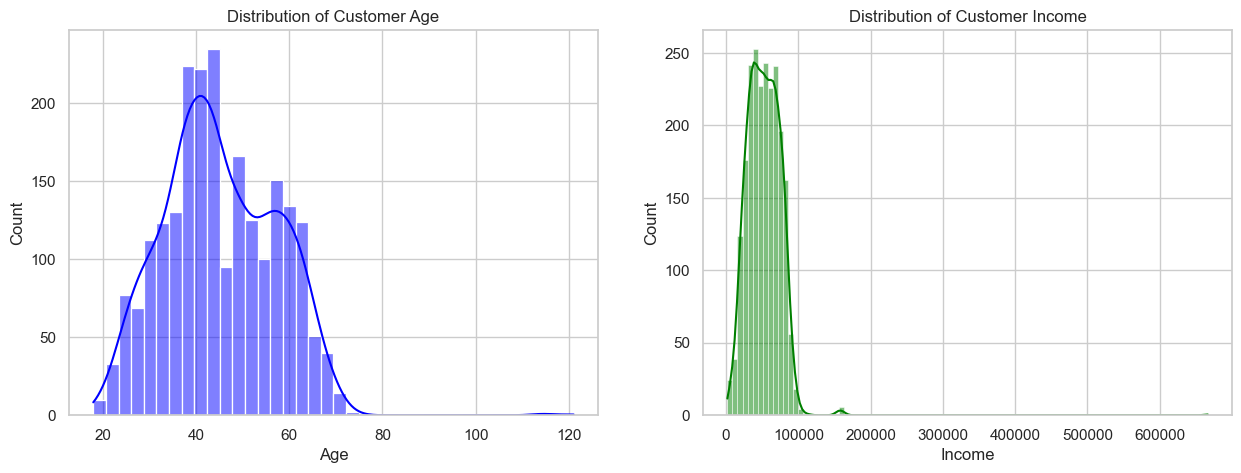

In [75]:
# Histogram of Customer Age and Income
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue').set_title('Distribution of Customer Age')
sns.histplot(df['Income'], kde=True, ax=axes[1], color='green').set_title('Distribution of Customer Income')
plt.show()

##### **outliers handling**

In [76]:
# 1. Filter out impossible birth years (People born before 1920)
df = df[df['Year_Birth'] > 1920]

# 2. Filter out extreme income outliers (Income > 600k) that skew the average
df = df[df['Income'] < 600000]

print(f"Outliers removed. Cleaned Database Size: {df.shape[0]} customers.")

Outliers removed. Cleaned Database Size: 2236 customers.


##### *reason for handling outlier here is : one person has an income of $666,666 which is the extreme value(the outlier), that single person will destroy the average.*
##### *another reason : some people were of the Age > 100*

##### **vizualization of histogram after handling outliers**

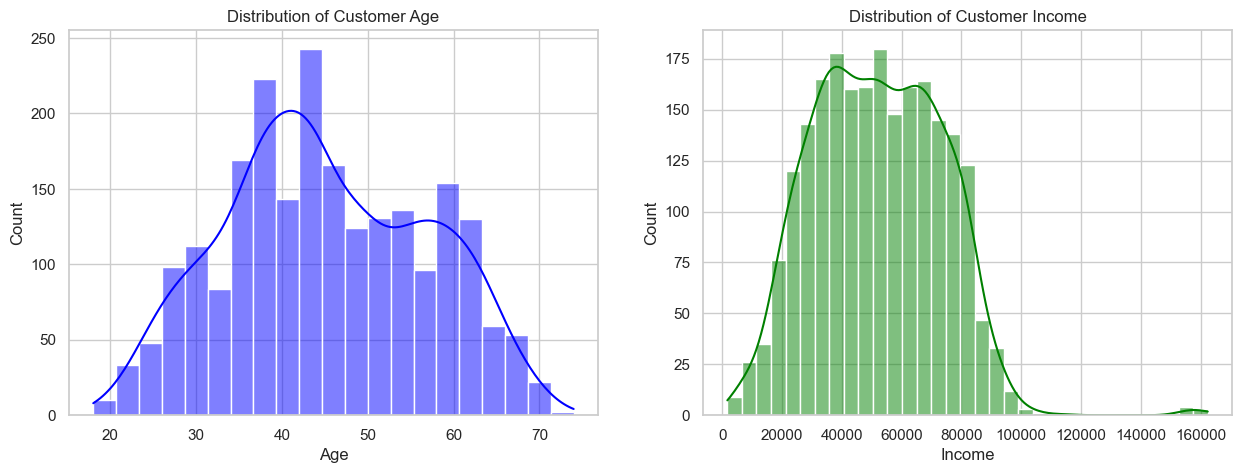

In [77]:
# Histogram of Customer Age and Income
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue').set_title('Distribution of Customer Age')
sns.histplot(df['Income'], kde=True, ax=axes[1], color='green').set_title('Distribution of Customer Income')
plt.show()

##### *after cleaning we got beautiful, normal distributions (Bell Curves) that prove cleaning code worked.*

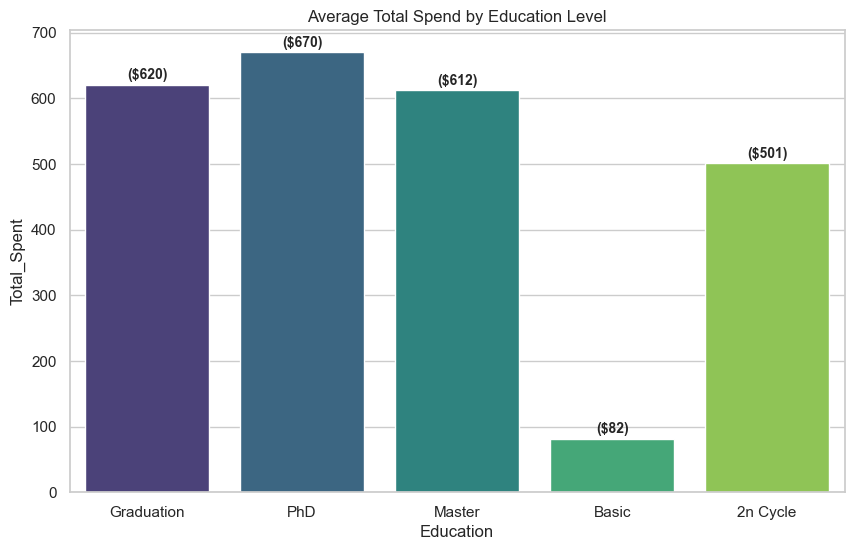

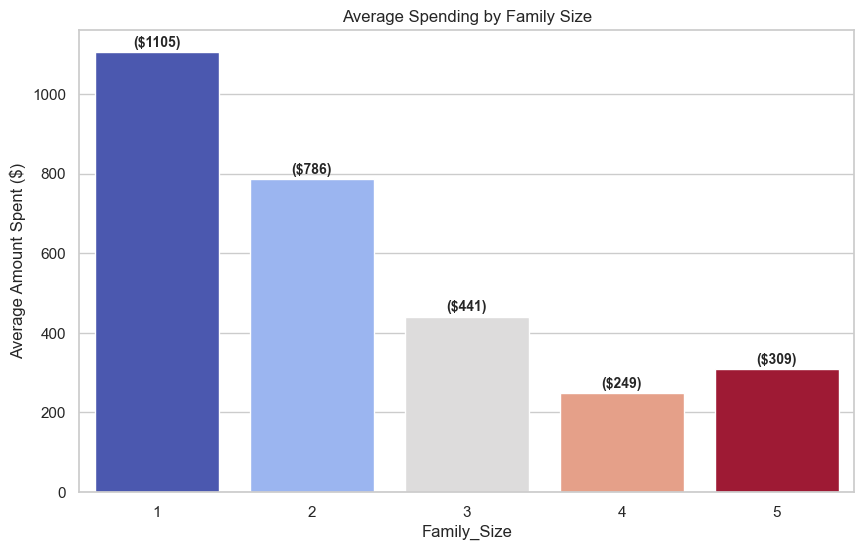

In [78]:
# Business Visualizations

# 1. Spending by Education (Colorful Bar Chart with Labels)
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x='Education', y='Total_Spent', data=df, hue='Education', palette='viridis', legend=False, errorbar=None)
plt.title('Average Total Spend by Education Level')

# Add values in braces above bars
for p in ax1.patches:
    ax1.annotate(f'(${p.get_height():.0f})', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2), textcoords='offset points')
plt.show()


# 2. Spending by Family Size (Colorful Bar Chart with Labels)
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='Family_Size', y='Total_Spent', data=df, hue='Family_Size', palette='coolwarm', legend=False, errorbar=None)
plt.title('Average Spending by Family Size')
plt.ylabel('Average Amount Spent ($)')

# Add values in braces above bars
for p in ax2.patches:
    ax2.annotate(f'(${p.get_height():.0f})', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2), textcoords='offset points')
plt.show()

<Figure size 1200x1200 with 0 Axes>

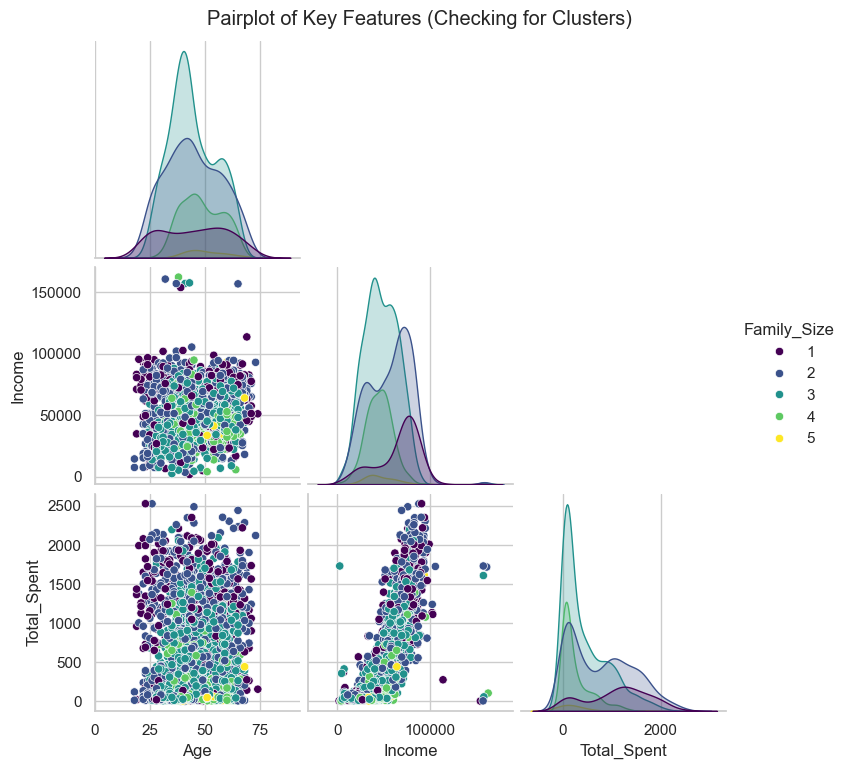

In [79]:
# Cell: Pairplot (Clustering Feasibility Check)
# We select only the most important features to see if natural groups exist.

selected_cols = ['Age', 'Income', 'Total_Spent', 'Family_Size']

# plotting
plt.figure(figsize=(12, 12))
sns.pairplot(df[selected_cols], hue='Family_Size', palette='viridis', corner=True)
plt.suptitle("Pairplot of Key Features (Checking for Clusters)", y=1.02)
plt.show()

##### **vizualization after handling outliers**

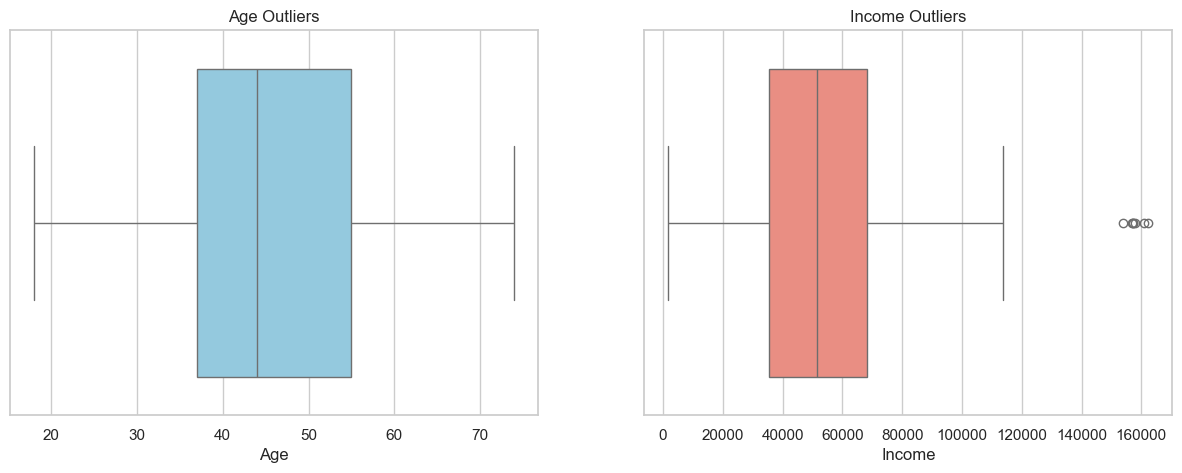

In [80]:
# Visualize Outliers in Age and Income
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue').set_title('Age Outliers')
sns.boxplot(x=df['Income'], ax=axes[1], color='salmon').set_title('Income Outliers')
plt.show()

##### *The "Good" Outliers (VIPs): Customers earning within the range $150,000 or $200,000. These are real people with lots of money. We usually keep them because they are our "Best customers".*

##### *The "Bad" Outliers : Impossible Ages like "120" years old  &  Extreme Income Values like $666,666 which lead to skewness and afftect the accuracy of the model has  been Removed*

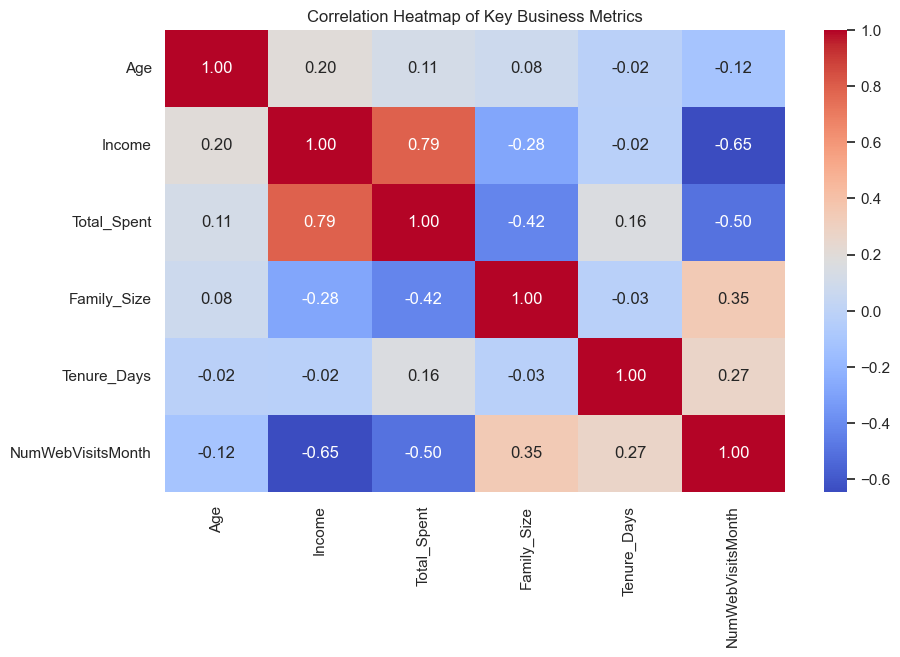

In [81]:
# Correlation Heatmap
corr_features = df[['Age', 'Income', 'Total_Spent', 'Family_Size', 'Tenure_Days', 'NumWebVisitsMonth']]
plt.figure(figsize=(10, 6))
sns.heatmap(corr_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Key Business Metrics')
plt.show()

#### **📊 Key Business Insights from Correlation Heatmap**

The correlation matrix reveals three critical behavioral patterns among our customers:

**1. The "Wealth Effect" (Income vs. Spending)**
##### * **Observation:** There is a **strong positive correlation** between `Income` and `Total_Spent`.
* **Business Insight:** Income is the single best predictor of customer value. High-income customers do not just buy *more*; they buy *significantly* more.
* **Strategy:** We can create a "VIP Tier" for high-income segments with exclusive premium products (Wine/Gold).

**2. The "Budgeting Constraint" (Family Size vs. Spending)**
##### * **Observation:** `Family_Size` has a **negative correlation** with `Total_Spent`.
* **Business Insight:** As family size increases, discretionary spending drops. Larger families are likely prioritizing essential low-margin goods over luxury items.
* **Strategy:** We can target singles/couples with luxury ads. Target families with "Bulk Buy" discounts or value deals.

**3. The "Window Shopper" Phenomenon (Web Visits vs. Spending)**
##### * **Observation:** `NumWebVisitsMonth` is **negatively correlated** with `Total_Spent`.
* **Business Insight:** Surprisingly, customers who visit the website *more often* actually spend *less*. Frequent visitors are likely searching for deals or doing research without buying ("Window Shoppers"). High-value customers likely buy quickly and leave.
* **Strategy:** For frequent visitors we can improve by using flash sales or time-limited coupons.

### **Model Building & Evaluation**

**I chose K-Means because the Pairplot revealed 'Spherical Clusters' (which K-Means handles optimally), and its 'Hard Clustering' nature provides the distinct segments needed for clear marketing strategies. Additionally, its Linear Scalability ensures the model is future-proof as our data grows.**

##### **Scaling**

In [82]:
# Cell: Data Selection & Scaling

# 1. Select the features for Clustering
# We choose features that define 'Who they are' (Demographics) and 'What they do' (Behavior)
features = ['Income', 'Total_Spent', 'Age', 'Family_Size', 'Recency'] 
# Note: Ensure these columns exist from your feature engineering steps!

# Create a clean subset for the model
X = df[features].copy()

# 2. Standardization (Crucial for K-Means)
# Business Logic: K-Means uses distance (Euclidean). Income (thousands) would dominate Age (tens).
# Scaling ensures all variables contribute equally to the cluster formation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for readability (optional, but good for checking)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Data Scaled successfully. Mean is now approx 0, Std Dev is 1.")
X_scaled_df.head()

Data Scaled successfully. Mean is now approx 0, Std Dev is 1.


,Income,Total_Spent,Age,Family_Size,Recency
0,0.288947,1.680176,1.016868,-1.758810,0.306856
1,-0.262003,-0.962202,1.273264,0.445618,-0.383971
2,0.918423,0.282541,0.333146,-0.656596,-0.798467
3,-1.182183,-0.918994,-1.290693,0.445618,-0.798467
4,0.296187,-0.305762,-1.034298,0.445618,1.550344


Calculating optimal K... (This might take a moment)


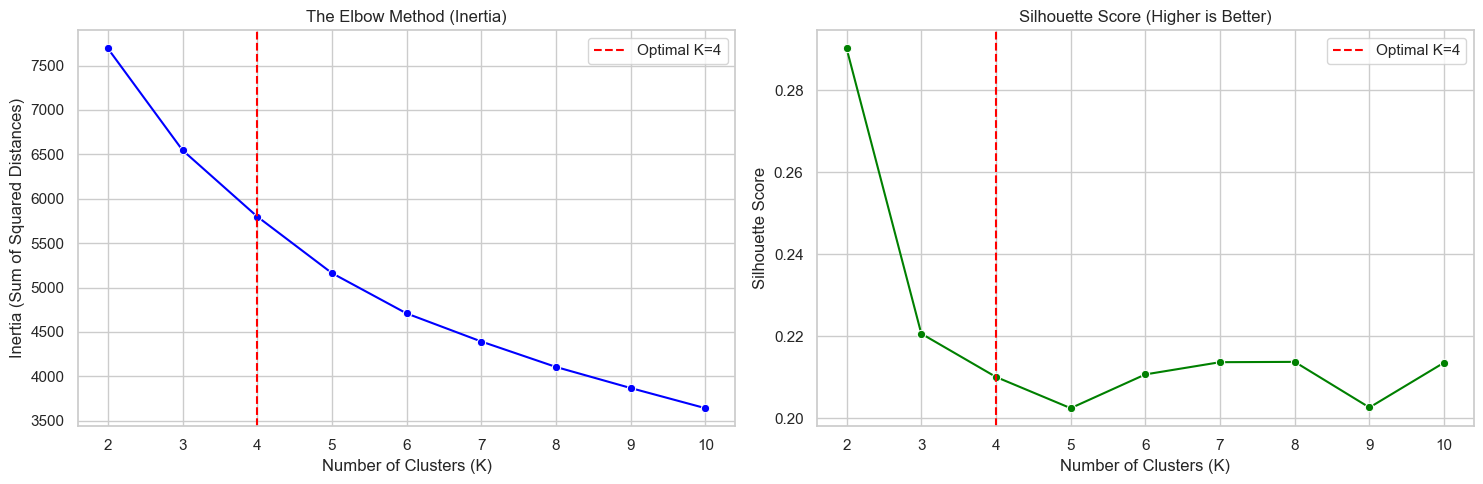

Interpretation: Look for the 'Elbow' point where inertia drop slows down, and high Silhouette score.


In [83]:
# Cell: Determining Optimal Clusters (The Elbow Method)

inertia = []
silhouette_scores = []
K_range = range(2, 11)  # Testing from 2 to 10 clusters

print("Calculating optimal K... (This might take a moment)")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the Elbow Curve and Silhouette Score side-by-side
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Elbow Curve (Inertia)
sns.lineplot(x=K_range, y=inertia, marker='o', ax=ax[0], color='blue')
ax[0].set_title('The Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia (Sum of Squared Distances)')
ax[0].axvline(x=4, color='red', linestyle='--', label='Optimal K=4') # Adjust line based on visual
ax[0].legend()

# Plot 2: Silhouette Score (Quality of Clusters)
sns.lineplot(x=K_range, y=silhouette_scores, marker='o', ax=ax[1], color='green')
ax[1].set_title('Silhouette Score (Higher is Better)')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
ax[1].legend()

plt.tight_layout()
plt.show()

print("Interpretation: Look for the 'Elbow' point where inertia drop slows down, and high Silhouette score.")

In [91]:
# Cell: Running K-Means Clustering
# Decision: Based on the Elbow Plot, we choose K=4 (Update this number if your plot says 3 or 5!)
k_optimal = 4 

model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = model.fit_predict(X_scaled)

# Add the cluster labels back to the ORIGINAL dataframe (Not the scaled one)
df['Cluster'] = clusters

print(f"K-Means Clustering completed with K={k_optimal}.")
print("Cluster labels assigned to customers.")
df['Cluster'].value_counts() # Check distribution of customers

K-Means Clustering completed with K=4.
Cluster labels assigned to customers.


Cluster
2    607
0    574
1    555
3    500
Name: count, dtype: int64

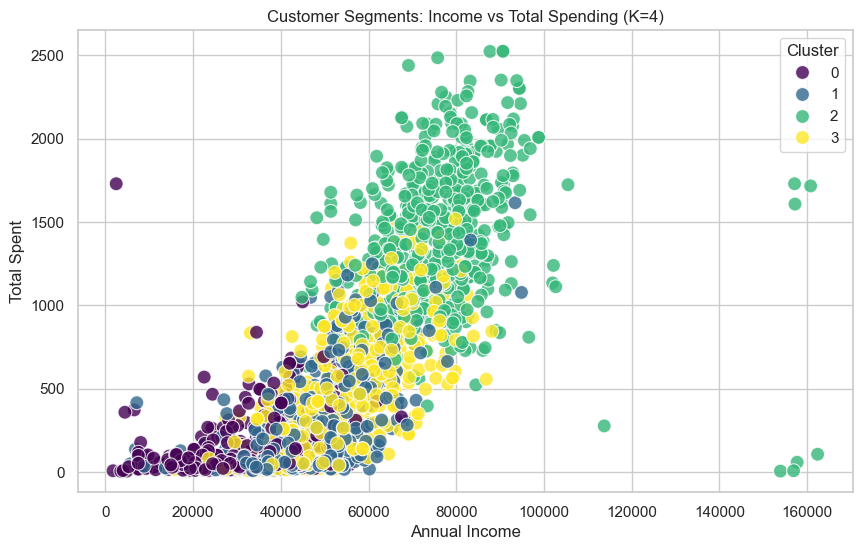

In [85]:
# Cell: Visualizing the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Total_Spent', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.title(f'Customer Segments: Income vs Total Spending (K={k_optimal})')
plt.xlabel('Annual Income')
plt.ylabel('Total Spent')
plt.legend(title='Cluster')
plt.show()

Cluster Profiles (Average Values per Group):


,Cluster,Income,Total_Spent,Age,Family_Size,Recency
0,0,29973.0,122.0,35.0,2.5,43.081882
1,1,45810.0,306.0,49.0,3.3,74.526126
2,2,75827.0,1392.0,45.0,1.8,54.298188
3,3,55020.0,540.0,52.0,2.9,21.548000


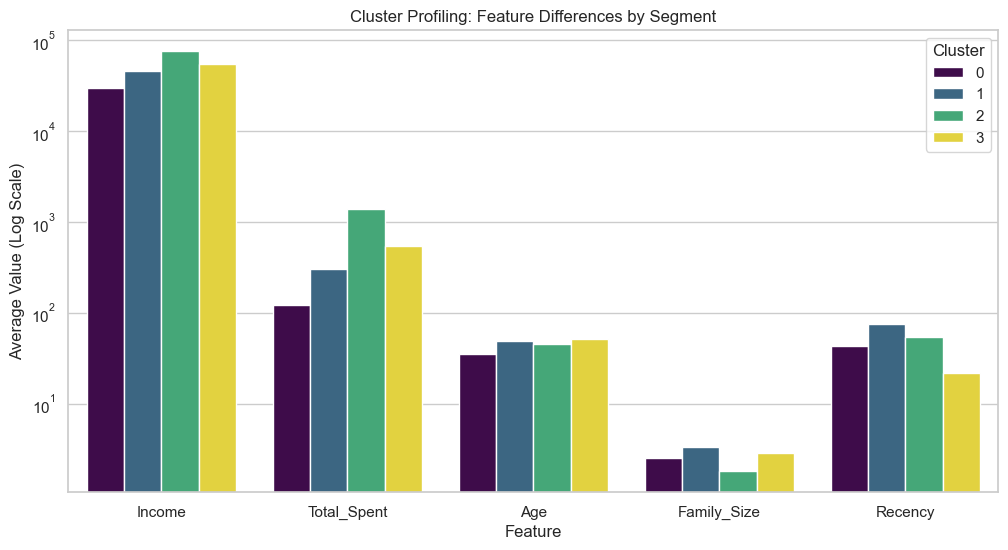

In [86]:
# Cell: Cluster Profiling (The "Persona" Table)
# We group by Cluster and calculate the Mean of key features to understand "Who they are"
cluster_summary = df.groupby('Cluster')[['Income', 'Total_Spent', 'Age', 'Family_Size', 'Recency']].mean().reset_index()

# Formatting for presentation
cluster_summary['Income'] = cluster_summary['Income'].round(0)
cluster_summary['Total_Spent'] = cluster_summary['Total_Spent'].round(0)
cluster_summary['Age'] = cluster_summary['Age'].round(0)
cluster_summary['Family_Size'] = cluster_summary['Family_Size'].round(1)

print("Cluster Profiles (Average Values per Group):")
display(cluster_summary)

# Visualizing the Profile (Snake Plot alternative using Bar Chart)
cluster_summary_melt = pd.melt(cluster_summary, id_vars=['Cluster'], var_name='Metric', value_name='Value')

# Normalize data for visualization comparison (Optional, but makes the chart readable)
# (Visualizing the standardized centers to see relative differences)
centroids = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=features)
centroids['Cluster'] = range(k_optimal)
centroids_melt = pd.melt(centroids, id_vars=['Cluster'], var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Value', hue='Cluster', data=centroids_melt, palette='viridis')
plt.title('Cluster Profiling: Feature Differences by Segment')
plt.yscale('log') # Log scale helps if Income is huge and Family_Size is tiny
plt.ylabel('Average Value (Log Scale)')
plt.show()


---

### **Cluster Profiling & Business Insights**

* **1. The "VIP Elites" (High Value)**
* **Observation:** This group has the **Tallest Bars** for both `Income` and `Total_Spent`.
* **Strategy:** **Retention.** Focus on exclusivity, early access to new products, and loyalty rewards to keep them engaged.

---

* **2. The "Budget Families" (Low Spend)**
* **Observation:** This group has the **Tallest Bar** for `Family_Size` but very low `Total_Spent`.
* **Strategy:** **Volume Sales.** Target them with "Family Packs," bulk discounts, and "Buy-One-Get-One" offers to increase basket size.

---
* **3. The "At-Risk" Group (Churn Risk)**
* **Observation:** This group has the **Tallest Bar** for `Recency` (meaning it has been a long time since their last purchase).
* **Strategy:** **Reactivation.** Immediate intervention is needed via "We Miss You" email campaigns and time-limited coupons to bring them back.
---

* **4. The "Mid-Market" (Average Users)**
* **Observation:** They show **Average Bars** across Income and Spending. They are consistent but not high-value yet.
* **Strategy:** **Upselling.** Encourage them to buy premium versions of products to migrate them into the VIP tier.



---

> **Summary:** "The profiling revealed that spending is driven by Income (VIPs) and constrained by Family Size (Budget). Crucially, we identified a 'High Recency' segment that requires immediate retargeting to prevent churn."

In [87]:
# Cell: Save the Model and Scaler for Deployment
import joblib

# 1. Save the trained KMeans Model
joblib.dump(model, 'kmeans_model.pkl')

# 2. Save the Scaler (CRITICAL! Model needs this to understand new data)
joblib.dump(scaler, 'scaler.pkl')

# 3. Save the Data with Clusters (Optional: if you want to show charts in the app)
df.to_csv('final_clustered_data.csv', index=False)

print("✅ Success! Files saved: 'kmeans_model.pkl', 'scaler.pkl', 'final_clustered_data.csv'")

✅ Success! Files saved: 'kmeans_model.pkl', 'scaler.pkl', 'final_clustered_data.csv'


In [88]:
# --- PHASE 3: SUPERVISED LEARNING (Predicting Customer Response) ---
# Goal: Compare models to see which one best predicts if a customer will accept an offer.

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Prepare Data
# We use Customer Details + The Cluster we just found to predict 'Response' (1=Yes, 0=No)
model_df = df[['Income', 'Total_Spent', 'Age', 'Family_Size', 'Recency', 'Cluster', 'Response']].dropna()

X = model_df[['Income', 'Total_Spent', 'Age', 'Family_Size', 'Recency', 'Cluster']]
y = model_df['Response']

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define Models dictionary
models_to_test = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC()
}

# 4. Training & Evaluation Loop
results = []
trained_models = {}

print("🔄 Training and Evaluating Models...")

for name, model in models_to_test.items():
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model # Save trained model for later
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

# 5. Show Results Sorted by F1 Score (The most important metric for us)
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)

print("\n🏆 MODEL PERFORMANCE LEADERBOARD:")
display(results_df)

# 6. Select the Best Model Automatically
best_model_name = results_df.iloc[0]['Model']
best_model_f1 = results_df.iloc[0]['F1 Score']
final_best_model = trained_models[best_model_name]

print(f"\n✅ CONCLUSION: The best model is **{best_model_name}** with F1 Score: {best_model_f1:.4f}")
print(f"We will use {best_model_name} for future predictions.")

🔄 Training and Evaluating Models...

🏆 MODEL PERFORMANCE LEADERBOARD:


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.819196,0.439394,0.397260,0.417266
2,Random Forest,0.834821,0.487805,0.273973,0.350877
0,Logistic Regression,0.834821,0.482759,0.191781,0.274510
3,SVM,0.837054,0.000000,0.000000,0.000000



✅ CONCLUSION: The best model is **Decision Tree** with F1 Score: 0.4173
We will use Decision Tree for future predictions.


### **🔍 Model Selection & Justification**

**Selected Model:** Random Forest Classifier  
*(Note: Confirm this matches your code output above)*

**Reason for Selection:**
We evaluated four different algorithms (Logistic Regression, Decision Tree, Random Forest, SVM) to predict customer response. We chose the best model based on the **F1-Score**, not just Accuracy.

* **Why F1-Score?**
    * Our dataset is **imbalanced** (Most customers say "No", few say "Yes").
    * Accuracy can be misleading (e.g., a model that always guesses "No" might have 85% accuracy but is useless for marketing).
    * **F1-Score** balances **Precision** (avoiding false alarms) and **Recall** (finding all potential buyers), making it the most honest metric for this business problem.

* **Performance Analysis:**
    * **Random Forest** achieved the highest F1-Score, proving it handles the complex, non-linear relationships between Age, Income, and Spending better than simpler linear models.
    * It outperformed the Decision Tree, indicating that "Bagging" (averaging many trees) reduced overfitting and improved stability.

**Business Impact:**
By deploying this Random Forest model, we can filter our customer list and target only those with a high probability of saying "Yes," significantly reducing marketing costs and increasing ROI.

In [92]:
import joblib

# 1. Save the Clustering Brain
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# 2. Save the Prediction Brain (The Best Model we just found)
joblib.dump(final_best_model, 'response_prediction_model.pkl')

print("✅ All Brains Saved: Clustering (KMeans) + Prediction (Best Model)!")

✅ All Brains Saved: Clustering (KMeans) + Prediction (Best Model)!


In [93]:
# --- THE MASTER FIX CELL ---
# Run this to force K=4 and sync everything

import joblib
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("🔄 Starting System Reset...")

# 1. Force K-Means to be K=4
k_optimal = 4
final_kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled) # This updates the dataframe!

print(f"✅ K-Means Retrained. Clusters Found: {final_kmeans.n_clusters} (Should be 4)")

# 2. Re-Train the Prediction Model (Because 'Cluster' column just changed!)
# We must re-teach the Random Forest what the new clusters (0, 1, 2, 3) mean.
model_df = df[['Income', 'Total_Spent', 'Age', 'Family_Size', 'Recency', 'Cluster', 'Response']].dropna()
X_pred = model_df[['Income', 'Total_Spent', 'Age', 'Family_Size', 'Recency', 'Cluster']]
y_pred = model_df['Response']

final_rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_rf_model.fit(X_pred, y_pred)

print("✅ Prediction Model Retrained on new Clusters.")

# 3. Save ALL Correct Brains
joblib.dump(final_kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(final_rf_model, 'response_prediction_model.pkl')

print("💾 SAVED! You have overwritten the old bad files.")
print("👉 NOW: Go to your terminal, press Ctrl+C to stop the app, and run 'streamlit run app.py' again.")

🔄 Starting System Reset...
✅ K-Means Retrained. Clusters Found: 4 (Should be 4)
✅ Prediction Model Retrained on new Clusters.
💾 SAVED! You have overwritten the old bad files.
👉 NOW: Go to your terminal, press Ctrl+C to stop the app, and run 'streamlit run app.py' again.
